# evaluation.ipynb - full-reproduction eval (retrieve + hybrid rerank)

Reconstruct `query_text` / `target_text` from the 0619 HEAL benchmark, resolve gold into the SDE pool, then rank with **BM25(top-200) union dense(top-300)**, min-max
normalized, hybrid weights **0.5 / 0.5**. Metrics: Top-1 / 5 / 10, plotted at the end.

**Benchmark**: strict canonical set - **HDP01011 excluded** 

**Models**: CTDS+NCIt+REDCap model (auto-discovered from `training_pipelines.py` output) plus
OpenAI `text-embedding-3-small`, BGE `bge-large-en-v1.5`, and CTDS-base as reference baselines.


In [1]:
# Cell 1 - OpenAI API key (never hardcode; export OPENAI_API_KEY in the shell before launching Jupyter)
import os
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
print("OpenAI key set (from env)." if OPENAI_API_KEY else
      "OpenAI key NOT set. `export OPENAI_API_KEY=...`, restart kernel, rerun. (Or set RUN_OPENAI=False in Cell 2.)")


OpenAI key set (from env).


In [2]:
# Cell 2 - Configuration (paths, models, frozen hybrid params)
from pathlib import Path
import datetime as _dt, re

# ------------------------------------------------------------------ BENCHMARK (same as full reproduction)
BENCHMARK_XLSX = Path("/opt/gpudata/fan1/heal_cde/ncit/benchmarks/HEAL_CDE_Mappings_0619.xlsx")
SDE_JSONL      = Path("/opt/gpudata/fan1/heal_cde/master_cde/master_sde_v2.jsonl")

# Full-reproduction study sheets ... but STRICT benchmark excludes HDP01011 (canonical 634-row set).
ALL_STUDY_SHEETS = ["HDP00895","HDP01476","HDP01340","HDP01498","HDP01495",
                    "HDP01329","HDP01011","HDP00933","HDP00429"]
EXCLUDE_SHEETS   = ["HDP01011"]                       # <-- strict benchmark: drop HDP01011
STUDY_SHEETS     = [s for s in ALL_STUDY_SHEETS if s not in EXCLUDE_SHEETS]
print("STRICT benchmark. excluded sheets:", EXCLUDE_SHEETS)
print("study sheets used:", STUDY_SHEETS)

# ------------------------------------------------------------------ MODEL BACKBONES
BASE_MODEL_NAME      = "uc-ctds/bge-large-en-v1.5-bio-mapping"   # base for both LoRA checkpoints
BGE_MODEL_NAME       = "BAAI/bge-large-en-v1.5"
CTDS_BASE_MODEL_NAME = "uc-ctds/bge-large-en-v1.5-bio-mapping"
OPENAI_EMBEDDING_MODEL = "text-embedding-3-small"

RUN_OPENAI = True   # set False to skip the OpenAI API model
RUN_CTDS   = True

# LoRA alpha used at TRAIN time (r=8 -> scaling alpha/r). Both checkpoints trained with alpha=16 (scaling 2.0).
LORA_ALPHA = 16

# ------------------------------------------------------------------ CHECKPOINTS TO EVALUATE
# >>> CHANGE THIS ONE LINE (must match training_pipelines.SANDBOX) <<<
SANDBOX = Path("/opt/gpudata/fan1/heal_cde/ncit/experiments/sandbox_myrun")
REPRO_ROOT = SANDBOX / "repro"   # reads Stage B checkpoints trained by training_pipelines.py
FULL_REPRO_STAGEB_ROOT = REPRO_ROOT / "stageB_redcap_15to1"
FULL_REPRO_CKPT_PATH = None   # e.g. ".../checkpoints/antidrift_0p1/biencoder_lora_step1052_epochfrac0p5_antidrift0p1.pt"

def discover_full_repro_ckpt():
    if FULL_REPRO_CKPT_PATH:
        p = Path(FULL_REPRO_CKPT_PATH); assert p.exists(), f"not found: {p}"; return p
    cands = sorted(FULL_REPRO_STAGEB_ROOT.glob("**/checkpoints/antidrift_*/*.pt"))
    assert cands, (f"No Stage B checkpoint under {FULL_REPRO_STAGEB_ROOT}. Set FULL_REPRO_CKPT_PATH explicitly.")
    def step_of(p):
        m = re.search(r"step(\d+)", p.name); return int(m.group(1)) if m else -1
    return max(cands, key=step_of)

# ------------------------------------------------------------------ FROZEN HYBRID RERANK (identical to full reproduction)
EMBEDDING_WEIGHT = 0.50
BM25_WEIGHT      = 0.50
DENSE_TOPK       = 300
BM25_TOPK        = 200
FINAL_RERANK_K   = 50
TOP_K_VALUES     = [1, 5, 10]
BM25_K1, BM25_B  = 1.2, 0.75

# ------------------------------------------------------------------ RUNTIME / OUTPUT
ENCODE_BATCH_SIZE = 128
OPENAI_BATCH_SIZE = 256
SEED = 42
DEDUP_POOL_BY_SDE_ID = True

RUN_ID   = _dt.datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR  = REPRO_ROOT / "eval_full_reproduction" / RUN_ID
EVAL_DIR = OUT_DIR / "eval"
CACHE_DIR = OUT_DIR / "cache"
for d in (OUT_DIR, EVAL_DIR, CACHE_DIR): d.mkdir(parents=True, exist_ok=True)
print("OUT_DIR:", OUT_DIR)
print("hybrid:", EMBEDDING_WEIGHT, "/", BM25_WEIGHT, "| dense", DENSE_TOPK, "| bm25", BM25_TOPK)


STRICT benchmark. excluded sheets: ['HDP01011']
study sheets used: ['HDP00895', 'HDP01476', 'HDP01340', 'HDP01498', 'HDP01495', 'HDP01329', 'HDP00933', 'HDP00429']
OUT_DIR: /opt/gpudata/fan1/heal_cde/ncit/experiments/sandbox_myrun/repro/eval_full_reproduction/20260706_125009
hybrid: 0.5 / 0.5 | dense 300 | bm25 200


In [3]:
# Cell 3 - Imports
import os
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
import re, json, math, random, gc, time
from collections import Counter, defaultdict
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from sentence_transformers import SentenceTransformer

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available(): print(torch.cuda.get_device_name(0))


device: cuda
NVIDIA H200 NVL


In [4]:
# Cell 4 - Load benchmark rows from the 0619 xlsx (one row per field with a gold element)
from openpyxl import load_workbook

def _s(x):
    if x is None: return ""
    if isinstance(x, float) and math.isnan(x): return ""
    return str(x).strip()
def _get(row, idx): return row[idx] if (idx is not None and idx < len(row)) else None

wb = load_workbook(str(BENCHMARK_XLSX), read_only=True, data_only=True)
print("sheets:", wb.sheetnames)

raw_rows = []
for sn in STUDY_SHEETS:
    if sn not in wb.sheetnames:
        print(f"  WARNING: sheet {sn} not found, skipping"); continue
    ws = wb[sn]; allr = list(ws.iter_rows(values_only=True))
    if not allr: continue
    hdr = allr[0]; ix = {c: i for i, c in enumerate(hdr) if c is not None}
    def col(*names):
        for n in names:
            if n in ix: return ix[n]
        return None
    c_fname=col("field_name"); c_ftype=col("field_type"); c_ftitle=col("field_title")
    c_fenum=col("field_enumLabels"); c_fcons=col("field_constraints"); c_fdesc=col("field_description")
    c_ename=col("element_name"); c_etitle=col("element_title")
    c_smid=col("standardsMappings.id","standardsMappings.id or ID","standardsMappings.id or ID:")
    for rownum, r in enumerate(allr[1:], start=2):
        fname=_get(r,c_fname); ename=_get(r,c_ename)
        if _s(fname)=="" or _s(ename)=="":  # need field AND gold element
            continue
        raw_rows.append({
            "benchmark": sn, "row_uid": f"{sn}:{rownum}:{_s(fname)}",
            "field_name":_s(fname),"field_type":_s(_get(r,c_ftype)),"field_title":_s(_get(r,c_ftitle)),
            "field_enumLabels":_s(_get(r,c_fenum)),"field_constraints":_s(_get(r,c_fcons)),
            "field_description":_s(_get(r,c_fdesc)),
            "element_name":_s(ename),"element_title":_s(_get(r,c_etitle)),
            "standards_id":_s(_get(r,c_smid)),
        })
query_df = pd.DataFrame(raw_rows)
print("benchmark eval rows:", len(query_df))
print(query_df["benchmark"].value_counts())

# strict-benchmark guard: excluded sheets must be absent from loaded rows
present = set(query_df["benchmark"].unique())
leaked = set(EXCLUDE_SHEETS) & present
assert not leaked, f"excluded sheet leaked into benchmark: {leaked}"
print("guard OK: excluded", EXCLUDE_SHEETS, "not present; sheets loaded:", sorted(present))


sheets: ['HEAL Studies', 'CDE_instruments', 'HDP00895', 'HDP01476', 'HDP01340', 'HDP01498', 'HDP01495', 'HDP01329', 'HDP01011', 'HDP00933', 'HDP00429']
benchmark eval rows: 684
benchmark
HDP01340    129
HDP01476     90
HDP00895     88
HDP01495     82
HDP01329     82
HDP00933     73
HDP00429     73
HDP01498     67
Name: count, dtype: int64
guard OK: excluded ['HDP01011'] not present; sheets loaded: ['HDP00429', 'HDP00895', 'HDP00933', 'HDP01329', 'HDP01340', 'HDP01476', 'HDP01495', 'HDP01498']


In [5]:
# Cell 5 - Reconstruct query_text (format: field_code_first_typed) -- identical to full reproduction
def parse_values(enum_labels: str) -> str:
    s = _s(enum_labels)
    if not s: return "[NO_VALUE]"
    if s.startswith("{") and ":" in s:
        kvs = re.findall(r"['\"]([^'\"]+)['\"]\s*:\s*['\"]([^'\"]*)['\"]", s)
        if kvs:
            codes = [k.strip() for k, _ in kvs]
            return ("; ".join(f"{k.strip()}={v.strip()}" for k, v in kvs) + " enum=" + " ".join(codes))
    parts = re.split(r"\s*\|\s*|\s*;\s*", s); pairs, codes = [], []
    for p in parts:
        p = p.strip()
        if not p: continue
        m = re.match(r"^\s*([^=,:]+)\s*[=,:]\s*(.+)$", p)
        if m:
            cv, lab = m.group(1).strip(), m.group(2).strip(); pairs.append(f"{cv}={lab}"); codes.append(cv)
        else:
            pairs.append(p)
    out = "; ".join(pairs)
    if codes: out += " enum=" + " ".join(codes)
    return out if out else "[NO_VALUE]"

def build_query_text(row) -> str:
    fname=_s(row["field_name"]); ftype=_s(row["field_type"])
    ftitle=_s(row["field_title"]); fdesc=_s(row["field_description"])
    desc = fdesc if fdesc else ftitle
    values = parse_values(row["field_enumLabels"])
    return (f"code: {fname} | variable_type: {ftype} | name: {ftitle} "
            f"| description: {desc} | values: {values}")

query_df["query_text"] = query_df.apply(build_query_text, axis=1)
print("example query_texts:")
for t in query_df["query_text"].head(3): print(" ", t[:150])


example query_texts:
  code: dob | variable_type: date | name: Date of birth | description: Contact Information: Date of birth | values: [NO_VALUE]
  code: age | variable_type: number | name: Age (years) | description: Contact Information: Age (years)[calculation: rounddown(datediff([dob],'today','y
  code: race___0 | variable_type: boolean | name: Race: American Indian/Alaska Native | description: Contact Information: Race[choice=American Indian/Al


In [6]:
# Cell 6 - Build SDE target pool and target_text (format: sde_code_name_desc_val) -- identical to full reproduction
def _v(x, empty):
    if x is None: return empty
    if isinstance(x, float) and math.isnan(x): return empty
    s = str(x).strip(); return s if s else empty

sde_objs = []
with open(SDE_JSONL) as f:
    for line in f:
        line = line.strip()
        if line: sde_objs.append(json.loads(line))
print("raw SDE rows:", len(sde_objs))

if DEDUP_POOL_BY_SDE_ID:
    seen=set(); dd=[]
    for o in sde_objs:
        sid=_s(o.get("sde_id"))
        if sid and sid in seen: continue
        seen.add(sid); dd.append(o)
    sde_objs = dd
    print("after dedup by sde_id:", len(sde_objs))

def build_target_text(o) -> str:
    return (f"sde_id: {_v(o.get('sde_id'),'')} | name: {_v(o.get('sde_name'),'')} "
            f"| type: {_v(o.get('sde_data_type'),'')} | description: {_v(o.get('sde_description'),'')} "
            f"| values: {_v(o.get('sde_permissible_values'),'[NO_VALUES]')} "
            f"| value_description: {_v(o.get('sde_pv_description'),'[NO_VALUE_DESCRIPTION]')} "
            f"| additional_info: {_v(o.get('sde_additional_info'),'[NO_ADDITIONAL_INFO]')} "
            f"| parent: {_v(o.get('sde_parent_name'),'')}")

target_work = pd.DataFrame({
    "target_index": range(len(sde_objs)),
    "sde_id":   [_s(o.get("sde_id")) for o in sde_objs],
    "sde_name": [_s(o.get("sde_name")) for o in sde_objs],
    "target_text": [build_target_text(o) for o in sde_objs],
})
target_texts = target_work["target_text"].tolist()
print("target pool size:", len(target_work))
print("example target_text:", target_texts[0][:180])


raw SDE rows: 56558
after dedup by sde_id: 56300
target pool size: 56300
example target_text: sde_id: aQO0VmltMn | name: Address City Name City | type: Text | description: The city or township for the address to describe where a mail piece is intended to be delivered. | val


In [7]:
# Cell 7 - Resolve each eval row's gold element -> target pool index -- identical to full reproduction
def norm_id(x): return re.sub(r"\s+","",_s(x)).lower()
def norm_nm(x): return re.sub(r"\s+"," ", re.sub(r"[^a-z0-9]+"," ", _s(x).lower())).strip()

id_to_idx={}; name_to_idx={}; nid_to_idx={}; nnm_to_idx={}
for i,o in enumerate(sde_objs):
    sid=_s(o.get("sde_id")); snm=_s(o.get("sde_name"))
    if sid and sid not in id_to_idx: id_to_idx[sid]=i
    if snm and snm not in name_to_idx: name_to_idx[snm]=i
    if sid: nid_to_idx.setdefault(norm_id(sid), i)
    if snm: nnm_to_idx.setdefault(norm_nm(snm), i)

def resolve_gold(row) -> List[int]:
    cands=[row["element_name"], row["element_title"], row["standards_id"]]
    for c in cands:
        c=_s(c)
        if c and c in id_to_idx: return [id_to_idx[c]]
    for c in cands:
        c=_s(c)
        if c and c in name_to_idx: return [name_to_idx[c]]
    for c in cands:
        c=_s(c)
        if c and norm_id(c) in nid_to_idx: return [nid_to_idx[norm_id(c)]]
    for c in cands:
        c=_s(c)
        if c and norm_nm(c) in nnm_to_idx: return [nnm_to_idx[norm_nm(c)]]
    return []

query_df["gold_indices"] = query_df.apply(resolve_gold, axis=1)
query_df["gold_in_pool"] = query_df["gold_indices"].apply(lambda x: len(x) > 0)
print(f"resolved: {query_df['gold_in_pool'].sum()} / {len(query_df)}")

eval_df = query_df[query_df["gold_in_pool"]].reset_index(drop=True).copy()
query_texts = eval_df["query_text"].tolist()
print("FINAL eval rows:", len(eval_df))
print(eval_df["benchmark"].value_counts())

# strict-benchmark guard: excluded sheets absent from FINAL eval set
assert not (set(EXCLUDE_SHEETS) & set(eval_df["benchmark"].unique())), "excluded sheet in eval_df!"
print("FINAL eval benchmarks:", sorted(eval_df["benchmark"].unique()))


resolved: 634 / 684
FINAL eval rows: 634
benchmark
HDP01340    128
HDP01476     86
HDP01329     82
HDP01495     81
HDP00429     73
HDP00933     72
HDP01498     59
HDP00895     53
Name: count, dtype: int64
FINAL eval benchmarks: ['HDP00429', 'HDP00895', 'HDP00933', 'HDP01329', 'HDP01340', 'HDP01476', 'HDP01495', 'HDP01498']


In [8]:
# Cell 8 - Eval helpers: BM25 + dense top-k + min-max hybrid -- identical to full reproduction
def tokenize(s): return re.findall(r"[a-z0-9]+", _s(s).lower())
def l2_normalize(x):
    x = np.asarray(x, dtype=np.float32)
    d = np.linalg.norm(x, axis=1, keepdims=True); d = np.maximum(d, 1e-12); return x / d

class SimpleBM25:
    def __init__(self, docs, k1=BM25_K1, b=BM25_B):
        self.doc_tokens=[tokenize(d) for d in docs]; self.n_docs=len(self.doc_tokens)
        self.k1=k1; self.b=b
        self.doc_lens=np.array([len(t) for t in self.doc_tokens],dtype=np.float32)
        self.avgdl=float(np.mean(self.doc_lens)) if self.n_docs else 0.0
        df=Counter(); postings={}
        for i,toks in enumerate(self.doc_tokens):
            for term,cnt in Counter(toks).items():
                df[term]+=1; postings.setdefault(term,[]).append((i,cnt))
        self.idf={t: math.log((self.n_docs-f+0.5)/(f+0.5)+1.0) for t,f in df.items()}
        self.postings=postings
    def topk(self, query, k):
        scores={}
        for term in tokenize(query):
            for di,freq in self.postings.get(term,[]):
                dl=self.doc_lens[di]
                denom=freq+self.k1*(1-self.b+self.b*dl/max(self.avgdl,1e-9))
                scores[di]=scores.get(di,0.0)+self.idf.get(term,0.0)*(freq*(self.k1+1.0))/max(denom,1e-9)
        if not scores: return np.array([],dtype=int), np.array([],dtype=np.float32)
        items=sorted(scores.items(), key=lambda x:x[1], reverse=True)[:k]
        return np.array([i for i,_ in items],dtype=int), np.array([s for _,s in items],dtype=np.float32)

def minmax_dict(d):
    if not d: return {}
    v=np.array(list(d.values()),dtype=np.float32); lo,hi=float(v.min()),float(v.max())
    if hi-lo<1e-12: return {k:0.0 for k in d}
    return {k:(val-lo)/(hi-lo) for k,val in d.items()}

@torch.no_grad()
def topk_search(query_emb, target_emb, k, chunk=2048):
    q=torch.as_tensor(query_emb,dtype=torch.float32,device=device)
    t=torch.as_tensor(target_emb,dtype=torch.float32,device=device)
    idx_out,sc_out=[],[]
    for s in range(0,q.shape[0],chunk):
        sims=q[s:s+chunk]@t.T
        sc,idx=torch.topk(sims,k=min(k,t.shape[0]),dim=1)
        idx_out.append(idx.cpu().numpy()); sc_out.append(sc.cpu().numpy())
    return np.concatenate(idx_out,0), np.concatenate(sc_out,0)


In [9]:
# Cell 9 - Robust LoRA loader (handles BOTH checkpoint layouts)
#  - full-repro Stage B: {"model_state_dict": <lora-only>}, keys "base_model.model.encoder.layer..."
#  - redcap5k:           {"model": <full BiEncoder state_dict>}, keys "encoder.base_model.model.encoder.layer..."
def _unwrap_state_dict(obj):
    if not isinstance(obj, dict): return obj, None
    base_name = obj.get("base_model_name")
    if torch.is_tensor(base_name): base_name = None
    for k in ("model_state_dict","state_dict","model","module"):
        if k in obj and isinstance(obj[k],dict) and all(torch.is_tensor(v) for v in obj[k].values()):
            return obj[k], base_name
    if obj and all(torch.is_tensor(v) for v in obj.values()):
        return obj, base_name
    raise AssertionError(f"could not find weights; top keys={list(obj.keys())[:20]}")

def load_lora_model(base_model_name, ckpt_path, device, alpha=None):
    alpha = LORA_ALPHA if alpha is None else alpha
    obj = torch.load(str(ckpt_path), map_location="cpu")
    msd, ckpt_base = _unwrap_state_dict(obj)
    base_name = ckpt_base or base_model_name
    st = SentenceTransformer(base_name, device=str(device))

    lora_keys = [k for k in msd if "lora_" in k.lower()]
    assert lora_keys, f"no LoRA keys in {ckpt_path} (top keys: {list(msd)[:8]})"
    from peft import LoraConfig, get_peft_model
    transformer = st[0].auto_model
    r_vals, targets = set(), set()
    for k in lora_keys:
        if "lora_A" in k: r_vals.add(msd[k].shape[0])
        m = re.search(r"\.([A-Za-z_]+)\.lora_[AB]\.", k)
        if m: targets.add(m.group(1))
    r = max(r_vals) if r_vals else 8
    target_modules = sorted(targets) or ["query","value"]
    print(f"LoRA: r={r} alpha={alpha} scaling={alpha/r:.3g} targets={target_modules} n_lora={len(lora_keys)}")
    cfg = LoraConfig(r=r, lora_alpha=alpha, target_modules=target_modules, lora_dropout=0.0, bias="none")
    peft_model = get_peft_model(transformer, cfg)
    pkeys = set(peft_model.state_dict().keys())

    remap = {}
    for k, v in msd.items():
        k2 = k[len("encoder."):] if k.startswith("encoder.") else k   # strip BiEncoder wrapper prefix
        for cand in (k, k2, f"base_model.model.{k}", f"base_model.model.{k2}",
                     k.replace("base_model.model.","",1), k2.replace("base_model.model.","",1)):
            if cand in pkeys:
                remap[cand] = v; break
    matched = [k for k in remap if "lora_" in k.lower()]
    assert len(matched) == len(lora_keys), (
        f"LoRA key mismatch: matched {len(matched)}/{len(lora_keys)}. "
        f"PEFT sample: {next(iter(pkeys))!r}; ckpt sample: {lora_keys[0]!r}")
    peft_model.load_state_dict(remap, strict=False); peft_model.eval()
    st[0].auto_model = peft_model; st.eval()
    print(f"LoRA load OK: applied all {len(matched)} adapter tensors (scaling={alpha/r:.3g}).")
    return st

FULL_REPRO_CKPT = discover_full_repro_ckpt()
print("full-repro checkpoint:", FULL_REPRO_CKPT)


full-repro checkpoint: /opt/gpudata/fan1/heal_cde/ncit/experiments/sandbox_myrun/repro/stageB_redcap_15to1/checkpoints/antidrift_0p1/biencoder_lora_step1052_epochfrac0p5_antidrift0p1.pt


In [10]:
# Cell 10 - Build BM25 once over the target pool (shared by all models)
print("Building BM25 over", len(target_texts), "targets ...")
bm25 = SimpleBM25(target_texts)
bm25_idx_scores = [bm25.topk(q, BM25_TOPK) for q in tqdm(query_texts, desc=f"bm25_top{BM25_TOPK}")]
print("BM25 ready.")


Building BM25 over 56300 targets ...


bm25_top200:   0%|          | 0/634 [00:00<?, ?it/s]

BM25 ready.


In [11]:
# Cell 11 - Per-row hybrid evaluator (shared) + encoders
def evaluate_model(model_key, query_emb, target_emb):
    query_emb=l2_normalize(query_emb); target_emb=l2_normalize(target_emb)
    dense_idx, dense_sc = topk_search(query_emb, target_emb, k=DENSE_TOPK)
    per_row=[]
    for i, row in eval_df.iterrows():
        gold=set(int(g) for g in row["gold_indices"])
        d_cands=[int(x) for x in dense_idx[i]]
        d_raw={ci:float(s) for ci,s in zip(d_cands, dense_sc[i])}
        d_rank={ci:r+1 for r,ci in enumerate(d_cands)}
        b_idx,b_sc=bm25_idx_scores[i]
        b_idx=[int(x) for x in b_idx[:BM25_TOPK]]
        b_raw={ci:float(s) for ci,s in zip(b_idx, b_sc[:BM25_TOPK])}
        d_norm,bnorm=minmax_dict(d_raw),minmax_dict(b_raw)
        union=set(d_raw)|set(b_raw)
        scored=sorted(({"ti":ci,"hybrid":EMBEDDING_WEIGHT*d_norm.get(ci,0.0)+BM25_WEIGHT*bnorm.get(ci,0.0)}
                       for ci in union), key=lambda x:x["hybrid"], reverse=True)
        gold_rank=np.nan
        for rank,it in enumerate(scored,start=1):
            if it["ti"] in gold: gold_rank=rank; break
        rec={"row_uid":row["row_uid"],"benchmark":row["benchmark"],
             "field_name":row["field_name"],"element_name":row["element_name"],
             "gold_rank":gold_rank,"in_union":bool(gold & union)}
        for k in TOP_K_VALUES:
            rec[f"hit{k}"]=bool(not np.isnan(gold_rank) and gold_rank<=k)
        per_row.append(rec)
    pr=pd.DataFrame(per_row); n=len(pr)
    print(f"[{model_key}] rows={n}  " + "  ".join(
        f"Top{k}={int(pr[f'hit{k}'].sum())} ({pr[f'hit{k}'].mean()*100:.1f}%)" for k in TOP_K_VALUES))
    pr.to_csv(EVAL_DIR / f"per_row_{model_key}.csv", index=False)
    return pr

def encode_st(model, texts):
    return model.encode(texts, batch_size=ENCODE_BATCH_SIZE, show_progress_bar=True,
                        convert_to_numpy=True, normalize_embeddings=True).astype(np.float32)

def embed_openai(texts, cache_path):
    cache_path=Path(cache_path)
    if cache_path.exists():
        arr=np.load(cache_path); print("loaded cache", cache_path.name, arr.shape); return arr.astype(np.float32)
    from openai import OpenAI
    client=OpenAI(api_key=os.environ["OPENAI_API_KEY"])
    rows=[]; clean=[t if isinstance(t,str) else "" for t in texts]
    for s in tqdm(range(0,len(clean),OPENAI_BATCH_SIZE), desc=cache_path.stem):
        batch=clean[s:s+OPENAI_BATCH_SIZE]
        for attempt in range(6):
            try:
                resp=client.embeddings.create(model=OPENAI_EMBEDDING_MODEL, input=batch)
                rows.extend([d.embedding for d in resp.data]); break
            except Exception as e:
                w=min(60,2**attempt); print(f"retry {attempt+1} @start={s}: {e}; sleep {w}s"); time.sleep(w)
        else:
            raise RuntimeError(f"OpenAI failed at start={s}")
    arr=l2_normalize(np.asarray(rows,dtype=np.float32)).astype(np.float32)
    np.save(cache_path, arr); print("saved", cache_path.name, arr.shape); return arr


In [12]:
# Cell 12 - Model registry + run all models through the SAME hybrid pipeline
MODELS = [
    {"key":"full_repro", "label":"Full-repro (15:1+anti-drift)", "kind":"lora",
     "path":FULL_REPRO_CKPT,    "base":BASE_MODEL_NAME, "color":"#d1495b"},
    {"key":"openai",     "label":"OpenAI (te-3-small)", "kind":"openai", "color":"#3b7dd8"},
    {"key":"bge",        "label":"BGE (bge-large-en-v1.5)", "kind":"st", "name":BGE_MODEL_NAME,       "color":"#2a9d8f"},
    {"key":"ctds",       "label":"CTDS-base",              "kind":"st", "name":CTDS_BASE_MODEL_NAME,  "color":"#9b9b9b"},
]
if not RUN_OPENAI: MODELS = [m for m in MODELS if m["key"] != "openai"]
if not RUN_CTDS:   MODELS = [m for m in MODELS if m["key"] != "ctds"]

per_row_by_key = {}
for spec in MODELS:
    key = spec["key"]; print("\n" + "="*70 + f"\nEncoding + evaluating: {key} ({spec['label']})")
    if spec["kind"] == "lora":
        model = load_lora_model(spec["base"], spec["path"], device)
        tgt = encode_st(model, target_texts); qry = encode_st(model, query_texts)
        del model
    elif spec["kind"] == "st":
        model = SentenceTransformer(spec["name"], device=str(device))
        tgt = encode_st(model, target_texts); qry = encode_st(model, query_texts)
        del model
    elif spec["kind"] == "openai":
        sm = OPENAI_EMBEDDING_MODEL.replace("-","_").replace(".","_")
        tgt = embed_openai(target_texts, CACHE_DIR / f"openai_{sm}_target.npy")
        qry = embed_openai(query_texts,  CACHE_DIR / f"openai_{sm}_query.npy")
    else:
        raise ValueError(spec["kind"])
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    per_row_by_key[key] = evaluate_model(key, qry, tgt)
    del qry, tgt; gc.collect()
print("\nAll models evaluated.")



Encoding + evaluating: full_repro (Full-repro (15:1+anti-drift))
LoRA: r=8 alpha=16 scaling=2 targets=['query', 'value'] n_lora=96
LoRA load OK: applied all 96 adapter tensors (scaling=2).


Batches:   0%|          | 0/440 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

[full_repro] rows=634  Top1=466 (73.5%)  Top5=564 (89.0%)  Top10=598 (94.3%)

Encoding + evaluating: openai (OpenAI (te-3-small))


openai_text_embedding_3_small_target:   0%|          | 0/220 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

[bge] rows=634  Top1=402 (63.4%)  Top5=528 (83.3%)  Top10=583 (92.0%)

Encoding + evaluating: ctds (CTDS-base)


Batches:   0%|          | 0/440 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

[ctds] rows=634  Top1=419 (66.1%)  Top5=564 (89.0%)  Top10=593 (93.5%)

All models evaluated.


In [13]:
# Cell 13 - Combine per-row ranks, headline scoreboard, sanity guard vs CTDS-base
def slim(df, tag):
    cols={"gold_rank":f"{tag}_rank","in_union":f"{tag}_in_union"}
    for k in TOP_K_VALUES: cols[f"hit{k}"]=f"{tag}_hit{k}"
    return df[["row_uid"]+list(cols)].rename(columns=cols)

first_key = MODELS[0]["key"]
base = per_row_by_key[first_key][["row_uid","benchmark","field_name","element_name"]].copy()
combined = base
for spec in MODELS:
    combined = combined.merge(slim(per_row_by_key[spec["key"]], spec["key"]), on="row_uid")
combined.to_csv(EVAL_DIR / "per_row_combined_ranks.csv", index=False)

n = len(combined)
print(f"=== headline (n = {n}) ===")
for k in TOP_K_VALUES:
    parts = []
    for spec in MODELS:
        key = spec["key"]
        short = spec["label"].split(" (")[0]
        hits = int(combined[key + f"_hit{k}"].sum())
        parts.append(f"{short}={hits}")
    print(f"Top{k}:  " + "  ".join(parts))

# sanity: each fine-tuned LoRA model must differ from CTDS-base (else the adapter didn't load)
if "ctds" in per_row_by_key:
    ctds_rank = combined["ctds_rank"].fillna(-1)
    for spec in MODELS:
        if spec["kind"] != "lora": continue
        key = spec["key"]
        this_rank = combined[key + "_rank"].fillna(-1)
        same = bool((this_rank == ctds_rank).all())
        if same:
            print(f"*** WARNING: {key} == CTDS-base on every row -> adapter NOT applied. Check Cell 9. ***")
        else:
            ndiff = int((this_rank != ctds_rank).sum())
            print(f"[ok] {key} differs from CTDS-base on {ndiff}/{n} rows.")
combined.head()


=== headline (n = 634) ===
Top1:  Full-repro=466  OpenAI=442  BGE=402  CTDS-base=419
Top5:  Full-repro=564  OpenAI=538  BGE=528  CTDS-base=564
Top10:  Full-repro=598  OpenAI=587  BGE=583  CTDS-base=593
[ok] full_repro differs from CTDS-base on 157/634 rows.


,row_uid,benchmark,field_name,element_name,full_repro_rank,full_repro_in_union,full_repro_hit1,full_repro_hit5,full_repro_hit10,openai_rank,...,bge_rank,bge_in_union,bge_hit1,bge_hit5,bge_hit10,ctds_rank,ctds_in_union,ctds_hit1,ctds_hit5,ctds_hit10
0,HDP00895:7:dob,HDP00895,dob,BRTHDTC,5,True,False,True,True,4,...,5,True,False,True,True,4,True,False,True,True
1,HDP00895:8:age,HDP00895,age,Age,11,True,False,False,False,8,...,9,True,False,False,True,28,True,False,False,False
2,HDP00895:11:race___0,HDP00895,race___0,AI_AN,8,True,False,False,True,1,...,5,True,False,True,True,10,True,False,False,True
3,HDP00895:12:race___1,HDP00895,race___1,Asian,1,True,True,True,True,1,...,5,True,False,True,True,1,True,True,True,True
4,HDP00895:13:race___2,HDP00895,race___2,Bl_AA,1,True,True,True,True,1,...,5,True,False,True,True,4,True,False,True,True


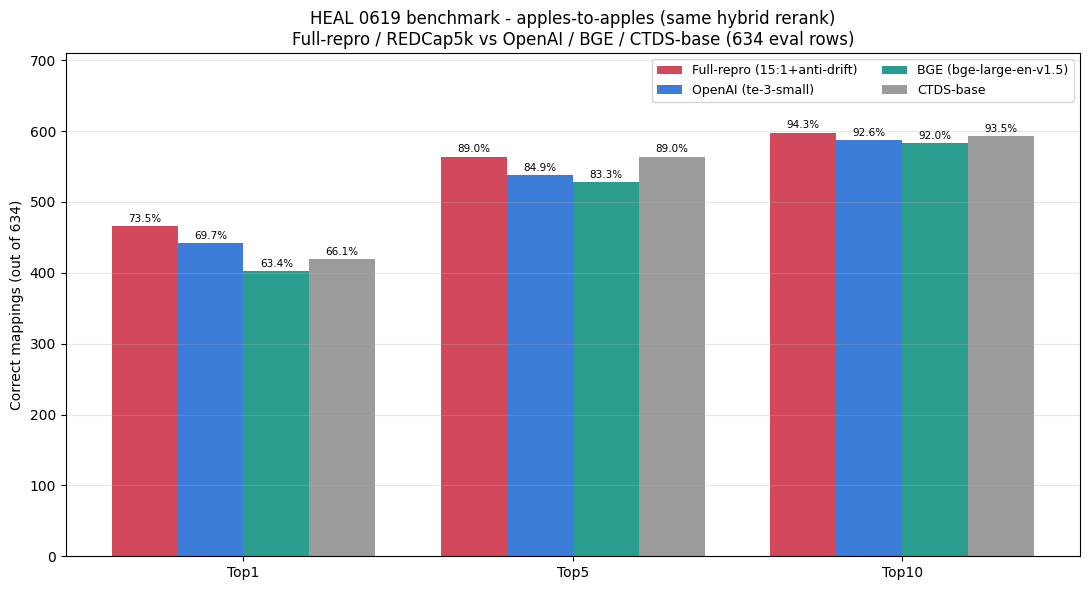

saved -> /opt/gpudata/fan1/heal_cde/ncit/experiments/sandbox_myrun/repro/eval_full_reproduction/20260706_125009/eval/topk_barplot_5models.png
Full-repro (15:1+anti-drift) {'Top1': 466, 'Top5': 564, 'Top10': 598}
OpenAI (te-3-small) {'Top1': 442, 'Top5': 538, 'Top10': 587}
BGE (bge-large-en-v1.5) {'Top1': 402, 'Top5': 528, 'Top10': 583}
CTDS-base {'Top1': 419, 'Top5': 564, 'Top10': 593}


In [14]:
# Cell 14 - Bar plot: Top-1 / Top-5 / Top-10 for all models
import matplotlib.pyplot as plt

ks = TOP_K_VALUES
n_eval = len(combined)
counts = {}
for spec in MODELS:
    key = spec["key"]
    counts[key] = [int(combined[key + f"_hit{k}"].sum()) for k in ks]

x = np.arange(len(ks)); width = 0.8 / len(MODELS)
fig, ax = plt.subplots(figsize=(11, 6))
for i, spec in enumerate(MODELS):
    key = spec["key"]
    bars = ax.bar(x + (i - (len(MODELS)-1)/2)*width, counts[key], width,
                  label=spec["label"], color=spec["color"])
    for b, c in zip(bars, counts[key]):
        ax.text(b.get_x()+b.get_width()/2, c + n_eval*0.005,
                f"{c/n_eval*100:.1f}%", ha="center", va="bottom", fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels([f"Top{k}" for k in ks])
ax.set_ylabel(f"Correct mappings (out of {n_eval})")
ax.set_title("HEAL 0619 benchmark - apples-to-apples (same hybrid rerank)\n"
             f"Full-repro / REDCap5k vs OpenAI / BGE / CTDS-base ({n_eval} eval rows)")
ax.legend(fontsize=9, ncol=2); ax.set_ylim(0, n_eval*1.12); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig_path = EVAL_DIR / "topk_barplot_5models.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight"); plt.show()
print("saved ->", fig_path)
for spec in MODELS:
    key = spec["key"]
    print(spec["label"], dict(zip([f"Top{k}" for k in ks], counts[key])))


In [15]:
# Cell 15 - Summary tables: overall + per-benchmark accuracy
overall_rows = []
for spec in MODELS:
    key = spec["key"]
    r = {"model": spec["label"], "n": n_eval}
    for k in ks:
        r[f"Top{k}"] = round(float(combined[key + f"_hit{k}"].mean())*100, 2)
    overall_rows.append(r)
overall = pd.DataFrame(overall_rows).sort_values("Top1", ascending=False).reset_index(drop=True)
print("=== ALL_COMBINED (accuracy %) ==="); display(overall)
overall.to_csv(EVAL_DIR / "summary_overall.csv", index=False)

per_bmk = []
for bmk, g in combined.groupby("benchmark"):
    for spec in MODELS:
        key = spec["key"]
        row = {"benchmark": bmk, "model": spec["label"], "n": len(g)}
        for k in ks:
            row[f"Top{k}"] = round(float(g[key + f"_hit{k}"].mean())*100, 2)
        per_bmk.append(row)
per_bmk_df = pd.DataFrame(per_bmk)
per_bmk_df.to_csv(EVAL_DIR / "summary_per_benchmark.csv", index=False)
top1_pivot = per_bmk_df.pivot(index="benchmark", columns="model", values="Top1")
print("=== per-benchmark Top-1 (%) ==="); display(top1_pivot)


=== ALL_COMBINED (accuracy %) ===


,model,n,Top1,Top5,Top10
0,Full-repro (15:1+anti-drift),634,73.50,88.96,94.32
1,OpenAI (te-3-small),634,69.72,84.86,92.59
2,CTDS-base,634,66.09,88.96,93.53
3,BGE (bge-large-en-v1.5),634,63.41,83.28,91.96


=== per-benchmark Top-1 (%) ===


model,BGE (bge-large-en-v1.5),CTDS-base,Full-repro (15:1+anti-drift),OpenAI (te-3-small)
benchmark,,,,
HDP00429,42.47,39.73,47.95,50.68
HDP00895,41.51,43.40,49.06,50.94
HDP00933,37.50,44.44,44.44,47.22
HDP01329,70.73,69.51,84.15,68.29
HDP01340,87.50,85.16,93.75,92.19
HDP01476,55.81,62.79,72.09,67.44
HDP01495,85.19,93.83,96.30,92.59
HDP01498,59.32,66.10,74.58,62.71


In [16]:
# Cell 16 - Save manifest
manifest = {
    "out_dir": str(OUT_DIR),
    "benchmark_xlsx": str(BENCHMARK_XLSX), "sde_jsonl": str(SDE_JSONL),
    "n_eval_rows": int(n_eval), "n_target_pool": int(len(target_work)),
    "hybrid": {"embedding_weight":EMBEDDING_WEIGHT,"bm25_weight":BM25_WEIGHT,
               "dense_topk":DENSE_TOPK,"bm25_topk":BM25_TOPK,"bm25_k1":BM25_K1,"bm25_b":BM25_B},
    "models": [{"key":s["key"],"label":s["label"],"kind":s["kind"],
                "path":str(s.get("path","")),"name":s.get("name","")} for s in MODELS],
    "full_repro_checkpoint": str(FULL_REPRO_CKPT),
    "redcap5k_checkpoint": str(REDCAP5K_CKPT_PATH),
    "outputs": {"barplot":str(EVAL_DIR/'topk_barplot_5models.png'),
                "combined_ranks":str(EVAL_DIR/'per_row_combined_ranks.csv'),
                "summary_overall":str(EVAL_DIR/'summary_overall.csv'),
                "summary_per_benchmark":str(EVAL_DIR/'summary_per_benchmark.csv')},
}
with open(OUT_DIR / "manifest.json","w") as f: json.dump(manifest, f, indent=2)
print(json.dumps(manifest, indent=2))


NameError: name 'REDCAP5K_CKPT_PATH' is not defined